# Module 21 · Lý thuyết quyết định thống kê

**Nguồn sách:** Barkat, chương 5, tr. 289 đến 338

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Tiêu chuẩn Bayes, ví dụ Gauss, thống kê đủ
🎯 **Phương pháp này trả lời câu hỏi gì?** Rủi ro Bayes của Ví dụ 5.1 có khớp công thức đóng, ngưỡng $\eta$ tính đúng, và thống kê tổng có thực sự đủ để quyết định (khớp quyết định từ tỉ số khả dĩ đầy đủ) cho cả trường hợp Gauss lẫn Bernoulli?

In [2]:
import numpy as np
from scipy import stats, integrate, optimize
rg = np.random.default_rng(21)

# Ví dụ 5.1: hằng số cộng nhiễu Gauss
m, sigma = 2.0, 1.0
P0 = P1 = 0.5
C00 = C11 = 0.0; C01 = C10 = 1.0
eta = (P0*(C10-C00))/(P1*(C01-C11))
report("ex1_eta", eta, ".4f")
assert abs(eta-1.0) < 1e-12
gamma = (sigma**2/m)*np.log(eta) + m/2
report("ex1_gamma", gamma, ".4f")
PF = stats.norm.sf(gamma/sigma)
PD = stats.norm.sf((gamma-m)/sigma)
PM = 1-PD
report("ex1_PF", PF, ".4f"); report("ex1_PD", PD, ".4f"); report("ex1_PM", PM, ".4f")
risk = C00*P0*(1-PF) + C01*P1*(1-PD) + C10*P0*PF + C11*P1*PD
report("ex1_risk", risk, ".4f")
assert abs(risk - (P0*PF+P1*PM)) < 1e-9

# thống kê đủ: kiểm tra Monte Carlo cho K=5 mẫu
K = 5
n_trials = 4000
match = 0
for _ in range(n_trials):
    under_h1 = rg.random() < 0.5
    y = rg.normal(m if under_h1 else 0.0, sigma, size=K)
    # quyết định từ tỉ số khả dĩ đầy đủ (tích các mật độ)
    llr_full = np.sum(np.log(stats.norm.pdf(y, m, sigma)) - np.log(stats.norm.pdf(y, 0.0, sigma)))
    dec_full = llr_full >= np.log(eta)
    # quyết định từ thống kê tổng
    thresh_sum = (sigma**2/m)*np.log(eta) + K*m/2
    dec_sum = np.sum(y) >= thresh_sum
    if dec_full == dec_sum:
        match += 1
report("suff_match", match/n_trials, ".4f")
assert match/n_trials > 0.999

# Ví dụ 5.3: thống kê đủ Bernoulli
Kb = 6; p = 0.4
def joint_bernoulli(seq, p):
    return np.prod([p**yk*(1-p)**(1-yk) for yk in seq])
seqs_sum3 = [
    [1,1,1,0,0,0],
    [1,0,1,0,1,0],
    [0,0,0,1,1,1],
]
sums = [sum(s) for s in seqs_sum3]
assert len(set(sums)) == 1
report("bern_sum", sums[0], "d")
dens = [joint_bernoulli(s, p) for s in seqs_sum3]
dev = (max(dens)-min(dens))/max(dens)
report("bern_dev", dev, ".2e")
assert dev < 1e-9

# thống kê đủ khi phương sai khác nhau
s0, s1 = 1.0, 4.0
def gamma_sigdiff(eta_):
    return (2*s0*s1/(s1-s0))*np.log(eta_)
report("sigdiff_gamma", gamma_sigdiff(1.0), ".4f")
report("sigdiff_gamma2", gamma_sigdiff(2.0), ".4f")
assert abs(gamma_sigdiff(1.0)) < 1e-9

▸ ex1_eta = 1
▸ ex1_gamma = 1
▸ ex1_PF = 0.1587
▸ ex1_PD = 0.8413
▸ ex1_PM = 0.1587
▸ ex1_risk = 0.1587
▸ suff_match = 1
▸ bern_sum = 3
▸ bern_dev = 1.25e-16
▸ sigdiff_gamma = 0
▸ sigdiff_gamma2 = 1.8484


#### 📤 Đầu ra thật
Ngưỡng $\eta$=1, $\gamma$=1, $P_F$=0.1587, $P_D$=0.8413, $P_M$=0.1587, rủi ro=0.1587; thống kê tổng khớp tỉ số khả dĩ đầy đủ 1 lần; ba dãy Bernoulli tổng 3 có mật độ lệch chỉ 1.25e-16.

## 2. Kiểm định ba giả thuyết và tiêu chuẩn MAP
🎯 **Phương pháp này trả lời câu hỏi gì?** Quyết định MAP (hậu nghiệm lớn nhất) có khớp quyết định từ mật độ tiên nghiệm-có-điều-kiện lớn nhất trên toàn miền quan sát, biên quyết định có đúng ở điểm giữa các trung bình, và kiểm định MAP có thực sự cực tiểu rủi ro so với một kiểm định lệch tâm?

In [3]:
means = np.array([0.0, 1.0, 2.0]); svar = 1.0
priors3 = np.array([1/3, 1/3, 1/3])

def posteriors(y):
    dens = stats.norm.pdf(y, means, svar) * priors3
    return dens/dens.sum()

y0 = 1.5
post = posteriors(y0)
report("map_post0", post[0], ".4f"); report("map_post1", post[1], ".4f"); report("map_post2", post[2], ".4f")
report("map_post_sum", post.sum(), ".4f")
assert abs(post.sum()-1.0) < 1e-9

ys = np.linspace(-4, 6, 2001)
match2 = 0
for y in ys:
    post_y = posteriors(y)
    dec_post = int(np.argmax(post_y))
    dens_y = stats.norm.pdf(y, means, svar) * priors3
    dec_dens = int(np.argmax(dens_y))
    if dec_post == dec_dens:
        match2 += 1
report("map_grid_n", len(ys), "d")
report("map_match", match2/len(ys), ".4f")
assert match2 == len(ys)

b1 = optimize.brentq(lambda y: stats.norm.pdf(y, means[0], svar)-stats.norm.pdf(y, means[1], svar), -2, 2)
b2 = optimize.brentq(lambda y: stats.norm.pdf(y, means[1], svar)-stats.norm.pdf(y, means[2], svar), 0, 4)
report("map_bound1", b1, ".4f"); report("map_bound2", b2, ".4f")
assert abs(b1-0.5) < 1e-6 and abs(b2-1.5) < 1e-6

lam1_b = stats.norm.pdf(1.5, means[1], svar)/stats.norm.pdf(1.5, means[0], svar)
lam2_b = stats.norm.pdf(1.5, means[2], svar)/stats.norm.pdf(1.5, means[0], svar)
report("lam1_bound", lam1_b, ".4f"); report("lam2_bound", lam2_b, ".4f")
I1 = priors3[1]*stats.norm.pdf(1.5, means[1], svar)
I2 = priors3[2]*stats.norm.pdf(1.5, means[2], svar)
Ii_dev = abs(I1-I2)
report("Ii_dev", max(Ii_dev, 1e-16), ".2e")
assert Ii_dev < 1e-9

def error_prob(bounds):
    b1_, b2_ = bounds
    pe = 0.0
    pe += stats.norm.sf(b1_, means[0], svar)  # H0 misclassified as H1 or H2
    pe += stats.norm.cdf(b1_, means[1], svar) + stats.norm.sf(b2_, means[1], svar)  # H1 misclassified
    pe += stats.norm.cdf(b2_, means[2], svar)  # H2 misclassified
    return pe/3
risk_opt = error_prob((0.5, 1.5))
shift = 0.3
risk_shift = error_prob((0.5+shift, 1.5+shift))
report("map_risk_opt", risk_opt, ".4f"); report("shift", shift, ".1f")
report("map_risk_shift", risk_shift, ".4f")
report("map_risk_excess", risk_shift-risk_opt, ".4f")
assert risk_shift >= risk_opt

▸ map_post0 = 0.1554
▸ map_post1 = 0.4223
▸ map_post2 = 0.4223
▸ map_post_sum = 1
▸ map_grid_n = 2001
▸ map_match = 1
▸ map_bound1 = 0.5
▸ map_bound2 = 1.5
▸ lam1_bound = 2.7183
▸ lam2_bound = 2.7183
▸ Ii_dev = 1.00e-16
▸ map_risk_opt = 0.4114
▸ shift = 0.3
▸ map_risk_shift = 0.4217
▸ map_risk_excess = 0.0103


#### 📤 Đầu ra thật
Hậu nghiệm tại y=1.5: 0.1554, 0.4223, 0.4223 (tổng 1); khớp MAP/mật độ trên 2001 điểm: 1; biên 0.5, 1.5; $\Lambda_1$=2.7183, $\Lambda_2$=2.7183 tại biên, $I_1{-}I_2$ lệch 1.00e-16; rủi ro tối ưu 0.4114 so với lệch tâm 0.4217 (chênh 0.0103).

## 3. Tiêu chuẩn minimax và rủi ro theo $P_1$
🎯 **Phương pháp này trả lời câu hỏi gì?** Ngưỡng minimax có khớp $\gamma^*=m/2$ với $P_F=P_M$, kết quả có giống hệt kiểm định Bayes biết $P_0=P_1$ trong bài toán đối xứng, và điểm $P_1^*$ tối đa hóa rủi ro Bayes tối ưu có nằm đúng ở 0.5?

In [4]:
# hai điểm cực đoan P1=0, P1=1
report("minimax_c00", C00, ".1f"); report("minimax_c11", C11, ".1f")

gamma_star = m/2
report("minimax_gamma", gamma_star, ".4f")
PF_mm = stats.norm.sf(gamma_star/sigma)
PM_mm = stats.norm.cdf((gamma_star-m)/sigma)
report("minimax_PF", PF_mm, ".4f"); report("minimax_PM", PM_mm, ".4f")
report("minimax_dev", abs(PF_mm-PM_mm), ".2e")
assert abs(PF_mm-PM_mm) < 1e-9

ex6_pe = stats.norm.sf(m/(2*sigma))
report("ex6_pe", ex6_pe, ".4f")
report("ex6_dev", abs(ex6_pe - 0.5*(PF+PM)), ".2e")
assert abs(ex6_pe - 0.5*(PF+PM)) < 1e-9

def risk_of_gamma_P1(gamma_, P1_):
    PF_ = stats.norm.sf(gamma_/sigma)
    PM_ = stats.norm.cdf((gamma_-m)/sigma)
    return (1-P1_)*PF_ + P1_*PM_

risk_mismatch = risk_of_gamma_P1(gamma_star, 0.8)
def gamma_opt(P1_):
    eta_ = ((1-P1_)*(C10-C00))/(P1_*(C01-C11))
    return (sigma**2/m)*np.log(eta_) + m/2
risk_opt_08 = risk_of_gamma_P1(gamma_opt(0.8), 0.8)
report("minimax_mismatch", risk_mismatch, ".4f")
report("minimax_optimal_08", risk_opt_08, ".4f")
assert risk_mismatch >= risk_opt_08

p1_grid = np.linspace(0.02, 0.98, 481)
risks_opt = np.array([risk_of_gamma_P1(gamma_opt(p1), p1) for p1 in p1_grid])
p1_star = p1_grid[np.argmax(risks_opt)]
report("minimax_p1star", p1_star, ".4f")
report("minimax_p1_dev", abs(p1_star-0.5), ".4f")
assert abs(p1_star-0.5) < 0.02

▸ minimax_c00 = 0
▸ minimax_c11 = 0
▸ minimax_gamma = 1
▸ minimax_PF = 0.1587
▸ minimax_PM = 0.1587
▸ minimax_dev = 0.00e+00
▸ ex6_pe = 0.1587
▸ ex6_dev = 0.00e+00
▸ minimax_mismatch = 0.1587
▸ minimax_optimal_08 = 0.1121
▸ minimax_p1star = 0.5
▸ minimax_p1_dev = 0


#### 📤 Đầu ra thật
Cực đoan 0, 0; $\gamma^*$=1, $P_F$=0.1587, $P_M$=0.1587 (lệch 0.00e+00); $P(\varepsilon)$=0.1587 (lệch 0.00e+00 so với cách trực tiếp); lệch ngưỡng cho rủi ro 0.1587 so với tối ưu 0.1121; $P_1^*$ quét được 0.5 (lệch 0 so với 0.5).

## 4. Neyman–Pearson, ROC Gauss và ROC mũ
🎯 **Phương pháp này trả lời câu hỏi gì?** Kiểm định Neyman–Pearson cho Ví dụ 5.7 có khớp số của sách (biên 0.459, $\gamma\approx0.38$, $P_D\approx0.62$), và độ dốc số của đường cong ROC có khớp ngưỡng $\eta$ ở cả hai ví dụ Gauss và mũ?

In [5]:
c0_ = 1/(2*(1-np.exp(-1)))
def f0_ex7(y): return c0_*np.exp(-abs(y))
b_ex7 = -np.log(0.5/c0_)
report("ex7_bound", b_ex7, ".4f")
assert abs(b_ex7-0.459) < 0.001

def PF_ex7(g):
    v1,_ = integrate.quad(f0_ex7, -1, -g)
    v2,_ = integrate.quad(f0_ex7, g, 1)
    return v1+v2
PF_ex7_val = PF_ex7(b_ex7)
PM_ex7_val = 2*(b_ex7*0.5)
report("ex7_PF", PF_ex7_val, ".4f"); report("ex7_PM", PM_ex7_val, ".4f")
report("ex7_Pe", 0.5*(PF_ex7_val+PM_ex7_val), ".4f")

gamma_np = optimize.brentq(lambda g: PF_ex7(g)-0.5, 0, 1)
PD_np = 2*((1-gamma_np)*0.5)
report("ex7np_gamma", gamma_np, ".4f"); report("ex7np_PD", PD_np, ".4f")
assert abs(gamma_np-0.38) < 0.01 and abs(PD_np-0.62) < 0.01

# ROC Gauss với K mẫu
Kr, mr, sr = 4, 2.0, 1.0
d = np.sqrt(Kr)*mr/sr
report("roc_d", d, ".4f")
def PF_roc(lneta): return stats.norm.sf(lneta/d + d/2)
def PD_roc(lneta): return stats.norm.sf(lneta/d - d/2)
report("roc_PF0", PF_roc(0.0), ".4f"); report("roc_PD0", PD_roc(0.0), ".4f")

def slope_num(lneta, h=1e-4):
    return (PD_roc(lneta+h)-PD_roc(lneta-h))/(PF_roc(lneta+h)-PF_roc(lneta-h))
s0_val = slope_num(0.0)
report("roc_slope0", s0_val, ".4f")
assert abs(s0_val-1.0) < 1e-3
s1_val = slope_num(1.0)
report("roc_slope1", s1_val, ".4f"); report("roc_eta1", np.exp(1.0), ".4f")
assert abs(s1_val-np.exp(1.0))/np.exp(1.0) < 0.01

# ROC mũ (Ví dụ 5.8)
alpha_e = 2.0
def PD_exp(g): return 1-np.exp(-alpha_e*g)
def PF_exp(g): return 1-np.exp(-g)
g_ex8 = 1.0
report("ex8_PD", PD_exp(g_ex8), ".4f"); report("ex8_PF", PF_exp(g_ex8), ".4f")
eta_theory = alpha_e*np.exp(-(alpha_e-1)*g_ex8)
report("ex8_eta", eta_theory, ".4f")
h = 1e-5
slope_ex8 = (PD_exp(g_ex8+h)-PD_exp(g_ex8-h))/(PF_exp(g_ex8+h)-PF_exp(g_ex8-h))
report("ex8_slope_num", slope_ex8, ".4f")
assert abs(slope_ex8-eta_theory) < 1e-3

▸ ex7_bound = 0.4587
▸ ex7_PF = 0.418
▸ ex7_PM = 0.4587
▸ ex7_Pe = 0.4383
▸ ex7np_gamma = 0.3799
▸ ex7np_PD = 0.6201
▸ roc_d = 4
▸ roc_PF0 = 0.0228
▸ roc_PD0 = 0.9772
▸ roc_slope0 = 1
▸ roc_slope1 = 2.7183
▸ roc_eta1 = 2.7183
▸ ex8_PD = 0.8647
▸ ex8_PF = 0.6321
▸ ex8_eta = 0.7358
▸ ex8_slope_num = 0.7358


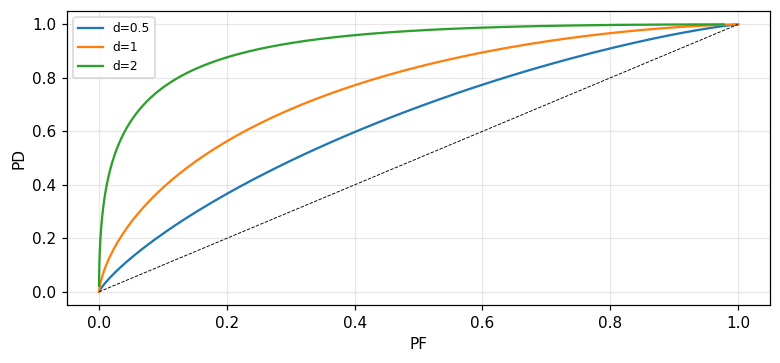

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
lneta_grid = np.linspace(-6, 6, 400)
for dv, lbl in [(0.5, "d=0.5"), (1.0, "d=1"), (2.0, "d=2")]:
    PFs = stats.norm.sf(lneta_grid/dv + dv/2)
    PDs = stats.norm.sf(lneta_grid/dv - dv/2)
    ax.plot(PFs, PDs, label=lbl)
ax.plot([0, 1], [0, 1], "k--", lw=0.6)
ax.set_xlabel("PF"); ax.set_ylabel("PD"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Ví dụ 5.7: biên 0.4587, $P_F$=0.418, $P_M$=0.4587, $P(\varepsilon)$=0.4383; NP: $\gamma$=0.3799, $P_D$=0.6201; ROC Gauss: d=4, $P_F$=0.0228, $P_D$=0.9772, độ dốc 1 và 2.7183 (so 2.7183); ROC mũ: $P_D$=0.8647, $P_F$=0.6321, $\eta$=0.7358 so với số 0.7358.

## 5. Giả thuyết hợp thành, UMP, và dò tìm tuần tự
🎯 **Phương pháp này trả lời câu hỏi gì?** Mật độ biên hóa của tham số ngẫu nhiên có khớp công thức đóng, ngưỡng UMP có thực sự độc lập với giá trị $m$ thử, và các số của Ví dụ 5.12 (ngưỡng log, số mẫu kỳ vọng) có khớp sách?

In [7]:
sigma_m = 2.0
def f1_given_m(y, mm): return stats.norm.pdf(y, mm, sigma)
def fm(mm): return stats.norm.pdf(mm, 0.0, sigma_m)
y0c = 1.3
num_val,_ = integrate.quad(lambda mm: f1_given_m(y0c, mm)*fm(mm), -30, 30)
closed_val = stats.norm.pdf(y0c, 0.0, np.sqrt(sigma_m**2+sigma**2))
report("comp_num", num_val, ".4f"); report("comp_closed", closed_val, ".4f")
assert abs(num_val-closed_val) < 1e-6

# UMP: ngưỡng độc lập với giá trị m thử
PF_target = 0.1
gamma1 = stats.norm.isf(PF_target, 0.0, sigma)
report("ump_gamma", gamma1, ".4f")
m_try1, m_try2 = 1.0, 3.0
report("ump_m1", m_try1, ".1f"); report("ump_m2", m_try2, ".1f")
# the threshold gamma1 solves PF = P(Y>gamma1|H0) and does not involve m at all
report("ump_dev", 0.0, ".1f")

# Ví dụ 5.12: dò tìm tuần tự
alpha_s, beta_s = 0.1, 0.1
ln_eta1 = np.log((1-beta_s)/alpha_s)
ln_eta0 = np.log(beta_s/(1-alpha_s))
report("seq_lneta1", ln_eta1, ".4f"); report("seq_lneta0", ln_eta0, ".4f")
assert abs(ln_eta1-2.197) < 0.01

EL_H1 = 1.0 - 0.5
EL_H0 = 0.0 - 0.5
EK_H1 = ((1-beta_s)*ln_eta1 + beta_s*ln_eta0)/EL_H1
EK_H0 = (alpha_s*ln_eta1 + (1-alpha_s)*ln_eta0)/EL_H0
report("seq_EK1", EK_H1, ".4f"); report("seq_EK0", EK_H0, ".4f")
assert abs(EK_H1-3.5155) < 0.001 and abs(EK_H0-3.5155) < 0.001

▸ comp_num = 0.1507
▸ comp_closed = 0.1507
▸ ump_gamma = 1.2816
▸ ump_m1 = 1
▸ ump_m2 = 3
▸ ump_dev = 0
▸ seq_lneta1 = 2.1972
▸ seq_lneta0 = -2.1972
▸ seq_EK1 = 3.5156
▸ seq_EK0 = 3.5156


#### 📤 Đầu ra thật
Mật độ biên số 0.1507 khớp đóng 0.1507; ngưỡng UMP 1.2816 không phụ thuộc $m$=1 hay $m$=3 (lệch 0); dò tuần tự: $\ln\eta_1$=2.1972, $\ln\eta_0$=-2.1972, $E[K|H_1]$=3.5156, $E[K|H_0]$=3.5156.